# Hebbian model -- learning dynamics exploration

In [1]:
import pandas as pd
import numpy as np
from experimental_setups import hebbian_model, isc_model
import data
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from experimental_setups.hebbian_model import SimpleHebbianModel

In [ ]:
error_data = []
num_epochs = 10

for alpha in np.linspace(0.05,1,30):
    print(f'Now training Hebbian model with alpha={alpha:.2f}...')
    error_data += hebbian_model.run_hebbian_experiment(num_epochs, alpha)
    print('\t...finished!\n')

error_data = pd.concat(error_data,axis=0)
error_data.to_csv('data/hebbian_alpha_experiment.csv')

Now training Hebbian model with alpha=0.05...
	...finished!
Now training Hebbian model with alpha=0.08...
	...finished!
Now training Hebbian model with alpha=0.12...
	...finished!
Now training Hebbian model with alpha=0.15...
	...finished!
Now training Hebbian model with alpha=0.18...
	...finished!
Now training Hebbian model with alpha=0.21...
	...finished!
Now training Hebbian model with alpha=0.25...
	...finished!
Now training Hebbian model with alpha=0.28...
	...finished!
Now training Hebbian model with alpha=0.31...
	...finished!
Now training Hebbian model with alpha=0.34...
	...finished!
Now training Hebbian model with alpha=0.38...
	...finished!
Now training Hebbian model with alpha=0.41...
	...finished!
Now training Hebbian model with alpha=0.44...
	...finished!
Now training Hebbian model with alpha=0.48...
	...finished!
Now training Hebbian model with alpha=0.51...
	...finished!
Now training Hebbian model with alpha=0.54...
	...finished!
Now training Hebbian model with alpha=0.

In [25]:
errs_alpha_interleaved = error_data
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['alpha']==0.05]
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['condition']=='interleaved']
errs_alpha_interleaved = errs_alpha_interleaved['acc'].mean()

In [ ]:
import matplotlib.pyplot as plt

alpha_plot_data = error_data.copy()
alphas = np.array(sorted(alpha_plot_data['alpha'].dropna().unique()))

mean_accs_blocked, mean_accs_interleaved = [], []
for alpha in alphas:
    errs_alpha_blocked = alpha_plot_data[
        (alpha_plot_data['alpha'] == alpha) &
        (alpha_plot_data['condition'] == 'blocked')
    ]['acc'].mean()

    errs_alpha_interleaved = alpha_plot_data[
        (alpha_plot_data['alpha'] == alpha) &
        (alpha_plot_data['condition'] == 'interleaved')
    ]['acc'].mean()

    mean_accs_blocked.append(errs_alpha_blocked)
    mean_accs_interleaved.append(errs_alpha_interleaved)

plt.plot(alphas, mean_accs_blocked, color='blue', label='Blocked')
plt.plot(alphas, mean_accs_interleaved, color='orange', label='Interleaved')

plt.title('The Effect of alpha value on Learning Dynamics')
plt.legend()
plt.xlabel('alpha')
plt.ylabel(f'Mean validation accuracy after {num_epochs} Epochs')

plt.show()


In [ ]:
error_data = pd.read_csv('data/hebbian_alpha_experiment_n40.csv')
errs_alpha_interleaved = error_data
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['alpha']==0.05]
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['condition']=='interleaved']
errs_alpha_interleaved = errs_alpha_interleaved['acc'].mean()

In [ ]:
import matplotlib.pyplot as plt

alpha_plot_data = error_data.copy()
alphas = np.array(sorted(alpha_plot_data['alpha'].dropna().unique()))

mean_accs_blocked, mean_accs_interleaved = [], []
for alpha in alphas:
    errs_alpha_blocked = alpha_plot_data[
        (alpha_plot_data['alpha'] == alpha) &
        (alpha_plot_data['condition'] == 'blocked')
    ]['acc'].mean()

    errs_alpha_interleaved = alpha_plot_data[
        (alpha_plot_data['alpha'] == alpha) &
        (alpha_plot_data['condition'] == 'interleaved')
    ]['acc'].mean()

    mean_accs_blocked.append(errs_alpha_blocked)
    mean_accs_interleaved.append(errs_alpha_interleaved)

plt.plot(alphas, mean_accs_blocked, color='blue', label='Blocked')
plt.plot(alphas, mean_accs_interleaved, color='orange', label='Interleaved')

plt.title('The Effect of alpha value on Learning Dynamics')
plt.legend()
plt.xlabel('alpha')
plt.ylabel(f'Mean validation accuracy after {num_epochs} Epochs')

plt.show()


What if we move the Oja weight updates to the task CCD layer?

In [25]:
error_data = []
num_epochs = 40

for alpha in np.linspace(0.05,1,30):
    print(f'Now training Hebbian model with alpha={alpha:.2f}...')
    error_data += hebbian_model.run_hebbian_experiment(num_epochs=num_epochs, alpha=alpha)
    print('\t...finished!\n')

error_data = pd.concat(error_data,axis=0)
error_data.to_csv('data/hebbian_alpha_taskcd.csv')

Now training Hebbian model with alpha=0.05...
	...finished!

Now training Hebbian model with alpha=0.08...
	...finished!

Now training Hebbian model with alpha=0.12...
	...finished!

Now training Hebbian model with alpha=0.15...
	...finished!

Now training Hebbian model with alpha=0.18...
	...finished!

Now training Hebbian model with alpha=0.21...
	...finished!

Now training Hebbian model with alpha=0.25...
	...finished!

Now training Hebbian model with alpha=0.28...
	...finished!

Now training Hebbian model with alpha=0.31...
	...finished!

Now training Hebbian model with alpha=0.34...
	...finished!

Now training Hebbian model with alpha=0.38...
	...finished!

Now training Hebbian model with alpha=0.41...
	...finished!

Now training Hebbian model with alpha=0.44...
	...finished!

Now training Hebbian model with alpha=0.48...
	...finished!

Now training Hebbian model with alpha=0.51...
	...finished!

Now training Hebbian model with alpha=0.54...
	...finished!

Now training Hebbian mod

In [27]:
errs_alpha_interleaved = error_data
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['alpha']==0.05]
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['condition']=='interleaved']
errs_alpha_interleaved = errs_alpha_interleaved['acc'].mean()

In [ ]:
import matplotlib.pyplot as plt

alpha_plot_data = error_data.copy()
alphas = np.array(sorted(alpha_plot_data['alpha'].dropna().unique()))

mean_accs_blocked, mean_accs_interleaved = [], []
for alpha in alphas:
    errs_alpha_blocked = alpha_plot_data[
        (alpha_plot_data['alpha'] == alpha) &
        (alpha_plot_data['condition'] == 'blocked')
    ]['acc'].mean()

    errs_alpha_interleaved = alpha_plot_data[
        (alpha_plot_data['alpha'] == alpha) &
        (alpha_plot_data['condition'] == 'interleaved')
    ]['acc'].mean()

    mean_accs_blocked.append(errs_alpha_blocked)
    mean_accs_interleaved.append(errs_alpha_interleaved)

plt.plot(alphas, mean_accs_blocked, color='blue', label='Blocked')
plt.plot(alphas, mean_accs_interleaved, color='orange', label='Interleaved')

plt.title('The Effect of alpha value on Learning Dynamics')
plt.legend()
plt.xlabel('alpha')
plt.ylabel(f'Mean validation accuracy after {num_epochs} Epochs')

plt.show()


Let's do online learning -- batch size of 1!

In [8]:
error_data = []
num_epochs = 40

for alpha in np.linspace(0.05,1,30):
    print(f'Now training Hebbian model with alpha={alpha:.2f}...')
    error_data += hebbian_model.run_hebbian_experiment(num_epochs=num_epochs, alpha=alpha, batch_size=1)
    print('\t...finished!\n')

error_data = pd.concat(error_data,axis=0)
error_data.to_csv('data/hebbian_alpha_online.csv')

Now training Hebbian model with alpha=0.05...
	...finished!

Now training Hebbian model with alpha=0.08...
	...finished!

Now training Hebbian model with alpha=0.12...
	...finished!

Now training Hebbian model with alpha=0.15...
	...finished!

Now training Hebbian model with alpha=0.18...
	...finished!

Now training Hebbian model with alpha=0.21...
	...finished!

Now training Hebbian model with alpha=0.25...
	...finished!

Now training Hebbian model with alpha=0.28...
	...finished!

Now training Hebbian model with alpha=0.31...
	...finished!

Now training Hebbian model with alpha=0.34...
	...finished!

Now training Hebbian model with alpha=0.38...
	...finished!

Now training Hebbian model with alpha=0.41...
	...finished!

Now training Hebbian model with alpha=0.44...
	...finished!

Now training Hebbian model with alpha=0.48...
	...finished!

Now training Hebbian model with alpha=0.51...
	...finished!

Now training Hebbian model with alpha=0.54...
	...finished!

Now training Hebbian mod

In [9]:
errs_alpha_interleaved = error_data
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['alpha']==0.05]
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['condition']=='interleaved']
errs_alpha_interleaved = errs_alpha_interleaved['acc'].mean()

In [ ]:
import matplotlib.pyplot as plt

alpha_plot_data = error_data.copy()
alphas = np.array(sorted(alpha_plot_data['alpha'].dropna().unique()))

mean_accs_blocked, mean_accs_interleaved = [], []
for alpha in alphas:
    errs_alpha_blocked = alpha_plot_data[
        (alpha_plot_data['alpha'] == alpha) &
        (alpha_plot_data['condition'] == 'blocked')
    ]['acc'].mean()

    errs_alpha_interleaved = alpha_plot_data[
        (alpha_plot_data['alpha'] == alpha) &
        (alpha_plot_data['condition'] == 'interleaved')
    ]['acc'].mean()

    mean_accs_blocked.append(errs_alpha_blocked)
    mean_accs_interleaved.append(errs_alpha_interleaved)

plt.plot(alphas, mean_accs_blocked, color='blue', label='Blocked')
plt.plot(alphas, mean_accs_interleaved, color='orange', label='Interleaved')

plt.title('The Effect of alpha value on Learning Dynamics')
plt.legend()
plt.xlabel('alpha')
plt.ylabel(f'Mean validation accuracy after {num_epochs} Epochs')

plt.show()


## Oja's rule exploration

Is Oja's rule working as expected to orthogonalize the representations here?

In [10]:
oja_test = OjaMiniModel(lr=1e-3)

device = torch.device("mps")

oja_test.to(device)

train_x,train_y,_,_,_,_ = data.make_behavioral_experiment_training_data(distractor_strength=.975)

# filter data to always contain category context
train_x = train_x[1][:20*19]
oja_test.train(train_x)

Cosine similarity: 0.08271816372871399
Weight norm: 0.022220440208911896
Cosine sim with context direction: 0.16849982738494873
Cosine similarity: 0.07908198237419128
Weight norm: 0.022167906165122986
Cosine sim with context direction: 0.1596967577934265
Cosine similarity: 0.07504472881555557
Weight norm: 0.022208981215953827
Cosine sim with context direction: 0.15010502934455872
Cosine similarity: 0.07051140815019608
Weight norm: 0.02234504744410515
Cosine sim with context direction: 0.14000214636325836
Cosine similarity: 0.06594681739807129
Weight norm: 0.02258060686290264
Cosine sim with context direction: 0.12905949354171753
Cosine similarity: 0.061179596930742264
Weight norm: 0.022917652502655983
Cosine sim with context direction: 0.11770262569189072
Cosine similarity: 0.056305937469005585
Weight norm: 0.023352552205324173
Cosine sim with context direction: 0.10605538636445999
Cosine similarity: 0.051459334790706635
Weight norm: 0.02388307824730873
Cosine sim with context directio

In [41]:
len(torch.unique(train_x, dim=0))

2

## New Oja-based model

In [2]:
error_data = []
num_epochs = 40

for alpha in np.linspace(0.05,1,30):
    print(f'Now training Hebbian model with alpha={alpha:.2f}...')
    error_data += hebbian_model.run_hebbian_experiment(num_epochs=num_epochs, alpha=alpha)
    print('\t...finished!\n')

error_data = pd.concat(error_data,axis=0)
error_data.to_csv('data/hebbian_alpha_new_setup.csv')

Now training Hebbian model with alpha=0.05...
	...finished!

Now training Hebbian model with alpha=0.08...
	...finished!

Now training Hebbian model with alpha=0.12...
	...finished!

Now training Hebbian model with alpha=0.15...
	...finished!

Now training Hebbian model with alpha=0.18...
	...finished!

Now training Hebbian model with alpha=0.21...
	...finished!

Now training Hebbian model with alpha=0.25...
	...finished!

Now training Hebbian model with alpha=0.28...
	...finished!

Now training Hebbian model with alpha=0.31...
	...finished!

Now training Hebbian model with alpha=0.34...
	...finished!

Now training Hebbian model with alpha=0.38...
	...finished!

Now training Hebbian model with alpha=0.41...
	...finished!

Now training Hebbian model with alpha=0.44...
	...finished!

Now training Hebbian model with alpha=0.48...
	...finished!

Now training Hebbian model with alpha=0.51...
	...finished!

Now training Hebbian model with alpha=0.54...
	...finished!

Now training Hebbian mod

In [7]:
errs_alpha_interleaved = error_data
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['alpha']==0.05]
errs_alpha_interleaved = errs_alpha_interleaved[errs_alpha_interleaved['condition']=='interleaved']
errs_alpha_interleaved = errs_alpha_interleaved['acc'].mean()

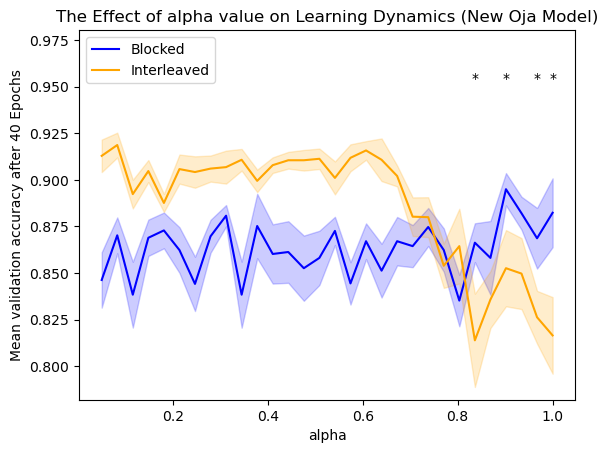

In [10]:
import matplotlib.pyplot as plt


def p_to_stars(p_value):
    if p_value < 0.001:
        return '***'
    if p_value < 0.01:
        return '**'
    if p_value < 0.05:
        return '*'
    return 'ns'


alpha_plot_data = pd.read_csv('data/hebbian_alpha_new_setup.csv')
try:
    alpha_val_acc_tests
except NameError:
    alpha_val_acc_tests = pd.read_csv('data/hebbian_alpha_new_setup_val_acc_tests.csv')

per_model_acc = (
    alpha_plot_data.groupby(['alpha', 'condition', 'model'], as_index=False)['acc']
    .mean()
)
summary = (
    per_model_acc.groupby(['alpha', 'condition'])['acc']
    .agg(['mean', 'sem'])
    .reset_index()
)

blocked_summary = summary[summary['condition'] == 'blocked'].sort_values('alpha')
interleaved_summary = summary[summary['condition'] == 'interleaved'].sort_values('alpha')

alphas = blocked_summary['alpha'].to_numpy()
mean_accs_blocked = blocked_summary['mean'].to_numpy()
std_accs_blocked = blocked_summary['sem'].fillna(0).to_numpy()
mean_accs_interleaved = interleaved_summary['mean'].to_numpy()
std_accs_interleaved = interleaved_summary['sem'].fillna(0).to_numpy()

fig, ax = plt.subplots()
ax.plot(alphas, mean_accs_blocked, color='blue', label='Blocked')
ax.fill_between(alphas, mean_accs_blocked - std_accs_blocked, mean_accs_blocked + std_accs_blocked,
                alpha=0.2, color='blue')

ax.plot(alphas, mean_accs_interleaved, color='orange', label='Interleaved')
ax.fill_between(alphas, mean_accs_interleaved - std_accs_interleaved, mean_accs_interleaved + std_accs_interleaved,
                alpha=0.2, color='orange')

star_y_values = []
y_offset = 0.012
# replace the star placement loop with this
sig_rows = alpha_val_acc_tests[alpha_val_acc_tests['p_value'] < 0.05]
if not sig_rows.empty:
    star_y = max(
        (mean_accs_blocked + std_accs_blocked).max(),
        (mean_accs_interleaved + std_accs_interleaved).max()
    ) + 0.025  # fixed height above all CI bands

    for _, row in sig_rows.iterrows():
        ax.text(row['alpha'], star_y, p_to_stars(row['p_value']),
                ha='center', va='bottom', fontsize=10, color='black')

    ax.set_ylim(bottom=ax.get_ylim()[0], top=star_y + 0.03)

ax.set_title('The Effect of alpha value on Learning Dynamics (New Oja Model)')
ax.legend()
ax.set_xlabel('alpha')
ax.set_ylabel(f'Mean validation accuracy after {num_epochs} Epochs')
if star_y_values:
    current_bottom, current_top = ax.get_ylim()
    ax.set_ylim(current_bottom, max(current_top, max(star_y_values) + 0.02))
plt.savefig('images/ema/alpha_grid_search')
plt.show()


In [6]:
from scipy.stats import ttest_ind

# Stats only: use validation accuracy exactly as stored in data/hebbian_alpha_new_setup.csv.
# The MAE hypothesis blocked > interleaved maps to validation accuracy blocked < interleaved.
error_data = pd.read_csv('data/hebbian_alpha_new_setup.csv')

seed_acc = (
    error_data.groupby(['alpha', 'condition', 'model'], as_index=False)['acc']
    .mean()
)

stat_rows = []
for alpha, alpha_data in seed_acc.groupby('alpha', sort=True):
    blocked = alpha_data[alpha_data['condition'] == 'blocked']['acc'].to_numpy()
    interleaved = alpha_data[alpha_data['condition'] == 'interleaved']['acc'].to_numpy()
    result = ttest_ind(blocked, interleaved, equal_var=False, alternative='greater')
    stat_rows.append({
        'alpha': alpha,
        'mean_blocked': blocked.mean(),
        'mean_interleaved': interleaved.mean(),
        'mean_diff': blocked.mean() - interleaved.mean(),
        'p_value': result.pvalue,
    })

alpha_val_acc_tests = pd.DataFrame(stat_rows)
alpha_val_acc_tests.to_csv('data/hebbian_alpha_new_setup_val_acc_tests.csv', index=False)
display(alpha_val_acc_tests)


,alpha,mean_blocked,mean_interleaved,mean_diff,p_value
0,0.050000,0.846316,0.912895,-0.066579,0.999200
1,0.082759,0.870263,0.918684,-0.048421,0.999620
2,0.115517,0.838421,0.892368,-0.053947,0.992160
3,0.148276,0.868947,0.904737,-0.035789,0.996612
4,0.181034,0.872895,0.887632,-0.014737,0.903704
5,0.213793,0.862368,0.905789,-0.043421,0.995518
6,0.246552,0.844211,0.904211,-0.060000,0.998509
7,0.279310,0.869737,0.906053,-0.036316,0.997526
8,0.312069,0.880789,0.906842,-0.026053,0.987293
9,0.344828,0.838421,0.910789,-0.072368,0.998704
